# BriefMe `arg_summ` — raw vs seq2seq mapping

## Setup

1. **Environment (recommended):** from repo root, `conda env create -f environment.yml`, `conda activate cs474`, `pip install -e ".[dev]"` — see [README.md](../README.md). Or: `pip install -r requirements.txt` in a venv and `pip install -e ".[dev]"`.
2. Copy `.env.example` to `.env` and set `HUGGINGFACE_HUB_TOKEN` ([create a token](https://huggingface.co/settings/tokens)).
3. Run this notebook with a kernel that has the project installed, or cwd = **repo root** / **`notebooks/`** (the first code cell adds `src/` to the path if `briefme` is not on `PYTHONPATH`).

**Colab:** put the token in Colab secrets or `os.environ["HUGGINGFACE_HUB_TOKEN"] = "..."` — `.env` is not loaded automatically.

Data is cached on disk under the Hugging Face cache (e.g. `~/.cache/huggingface/datasets`), not in a SQL/NoSQL database.

**Note:** Full `load_dataset(..., streaming=False)` can fail while building cache (upstream issue on the empty `held_out` split vs schema). This notebook uses **streaming + materialize first N rows** via `briefme.data` so EDA runs reliably.

In [8]:
from __future__ import annotations

import os
import sys
from pathlib import Path

from dotenv import load_dotenv


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src" / "briefme").is_dir():
        return cwd
    if (cwd.parent / "src" / "briefme").is_dir():
        return cwd.parent
    return cwd


REPO_ROOT = _repo_root()
SRC_ROOT = REPO_ROOT / "src"

try:
    import briefme as _briefme_check  # noqa: F401
except ImportError:
    if SRC_ROOT.is_dir():
        sys.path.insert(0, str(SRC_ROOT))

load_dotenv(REPO_ROOT / ".env")

from datasets import get_dataset_config_names

from briefme.data import (
    SPLIT_DEV,
    SPLIT_TEST,
    SPLIT_TRAIN,
    load_arg_summ_split_streaming,
    materialize_head,
)
from briefme.schema import (
    CONFIG_NAME,
    DATASET_NAME,
    SOURCE_COLUMN,
    TARGET_COLUMN,
    to_seq2seq_example,
)

if not (os.getenv("HUGGINGFACE_HUB_TOKEN") or os.getenv("HF_TOKEN")):
    print(
        "Note: No HUGGINGFACE_HUB_TOKEN / HF_TOKEN set. "
        "Public datasets may still load; gated repos need .env (see .env.example)."
    )

In [9]:
configs = get_dataset_config_names(DATASET_NAME)
print("Available configs:", configs)
assert CONFIG_NAME in configs, f"Expected {CONFIG_NAME} in {configs}"

# Streaming avoids Hub cache failure on held_out split (see notebook intro).
EDA_N = 2000  # materialize this many train rows for plots + samples
train_eda = materialize_head(load_arg_summ_split_streaming(SPLIT_TRAIN), EDA_N)
print("Materialized train head:", len(train_eda), "rows")
print("Features:\n", train_eda.features)
print("Hub splits (streaming): train, dev, test — use load_arg_summ_split_streaming(name)")

Available configs: ['arg_comp', 'arg_summ', 'case_retrieval', 'retrieval_corpus', 'preprocessed']
Materialized train head: 2000 rows
Features:
 {'file': Value('string'), 'text': Value('string'), 'reference': Value('string'), 'judge_outcome': Value('string'), 'judge_score_verb': Value('string'), 'judge_score': Value('int64')}
Hub splits (streaming): train, dev, test — use load_arg_summ_split_streaming(name)


In [10]:
train = train_eda
n_show = min(3, len(train))
print(f"Showing {n_show} raw rows (columns: text, reference, file, judge_* )\n")
for i in range(n_show):
    row = train[i]
    print("===", i, "===")
    print("file:", row.get("file"))
    print("reference (gold heading):", row.get("reference"))
    print("text (excerpt):", (row.get("text") or "")[:800], "..." if len(row.get("text") or "") > 800 else "")
    print()

Showing 3 raw rows (columns: text, reference, file, judge_* )

=== 0 ===
file: Docket19-930_Brief002.pdf
reference (gold heading): INTRODUCTION: THE CURRENT SCOPE OF THE AIA AS INTERPRETED BY THE SIXTH CIRCUIT REACHES TOO BROADLY
text (excerpt): It may seem odd that a low-income taxpayer clinic 
is weighing in on a case involving a tax advisor to 
§ 831(b) captive insurance companies. After all, our clients generally do not encounter the same type of tax 
shelter scrutiny facing CIC Services (hereinafter CIC). 
However, this case exposes a fundamental tension be-tween the Administrative Procedure Act (APA) and the 
Anti-Injunction Act (AIA) which, if resolved incorrectly, 
would disproportionately harm low-income taxpayers.  
4 
  The Tax Clinic made a similar argument to the 
Second Circuit in the case of Larson v. United States , 
888 F.3d 578 (2d Cir. 2018), which also involved activ-
ity targeted by the IRS as a tax shelter. While the Larson  case differs factually  and procedurall

In [11]:
print("Mapped seq2seq pairs: source =", repr(SOURCE_COLUMN), " target =", repr(TARGET_COLUMN))
for i in range(n_show):
    ex = to_seq2seq_example(train[i])
    print("===", i, "===")
    print("metadata:", ex["metadata"])
    print("target:", ex["target"])
    print("source (excerpt):", ex["source"][:800], "..." if len(ex["source"]) > 800 else "")
    print()

Mapped seq2seq pairs: source = 'text'  target = 'reference'
=== 0 ===
metadata: {'file': 'Docket19-930_Brief002.pdf'}
target: INTRODUCTION: THE CURRENT SCOPE OF THE AIA AS INTERPRETED BY THE SIXTH CIRCUIT REACHES TOO BROADLY
source (excerpt): It may seem odd that a low-income taxpayer clinic 
is weighing in on a case involving a tax advisor to 
§ 831(b) captive insurance companies. After all, our clients generally do not encounter the same type of tax 
shelter scrutiny facing CIC Services (hereinafter CIC). 
However, this case exposes a fundamental tension be-tween the Administrative Procedure Act (APA) and the 
Anti-Injunction Act (AIA) which, if resolved incorrectly, 
would disproportionately harm low-income taxpayers.  
4 
  The Tax Clinic made a similar argument to the 
Second Circuit in the case of Larson v. United States , 
888 F.3d 578 (2d Cir. 2018), which also involved activ-
ity targeted by the IRS as a tax shelter. While the Larson  case differs factually  and procedurally f

Source (text) char length — min=89  p50=4978  p90=13030  p95=17223  p99=41037  max=162700
Rows with length > p99: 20 (1.00%) → thin right tail



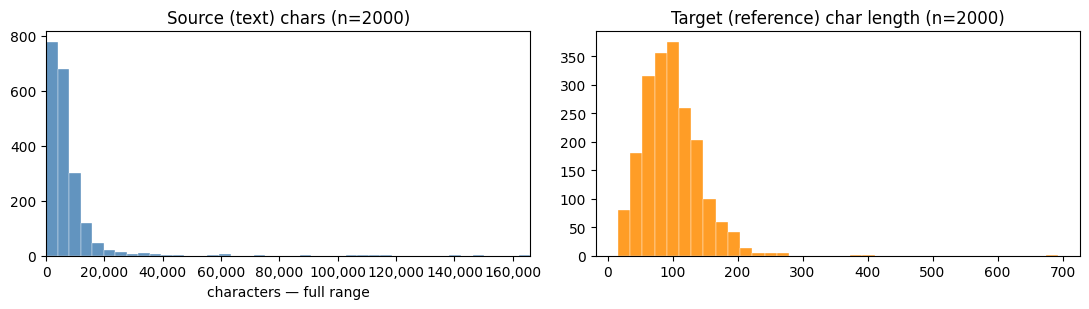

In [12]:
# Length distribution (character counts) — check right tail on source text, then zoom x-axis sensibly
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

comma_ticks = FuncFormatter(lambda x, p: f"{x:,.0f}")

sample_n = len(train)
src_lens = [len(train[i][SOURCE_COLUMN] or "") for i in range(sample_n)]
tgt_lens = [len(train[i][TARGET_COLUMN] or "") for i in range(sample_n)]

src_arr = np.asarray(src_lens, dtype=np.float64)
p50, p90, p95, p99 = np.percentile(src_arr, [50, 90, 95, 99])
mx = float(src_arr.max())
mn = float(src_arr.min())
n_gt_p99 = int(np.sum(src_arr > p99))
frac_gt_p99 = n_gt_p99 / sample_n
# Thin tail = few rows past p99 relative to bulk (long documents are rare)
thin_right_tail = n_gt_p99 <= max(10, round(0.015 * sample_n))

print(f"Source ({SOURCE_COLUMN}) char length — min={mn:.0f}  p50={p50:.0f}  p90={p90:.0f}  p95={p95:.0f}  p99={p99:.0f}  max={mx:.0f}")
print(f"Rows with length > p99: {n_gt_p99} ({100 * frac_gt_p99:.2f}%) → {'thin right tail' if thin_right_tail else 'LONG right tail — x-axis capped at p99 for main view'}")
print()

# Source hist: zoom to bulk; cap at p99 only when tail is visibly heavy so the peak is centered in view
src_xmax = mx * 1.02 if thin_right_tail else p99

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(src_lens, bins=42, range=(0.0, src_xmax), color="steelblue", alpha=0.85, edgecolor="white", linewidth=0.3)
ax[0].set_xlim(0.0, src_xmax)
ax[0].set_title(f"Source ({SOURCE_COLUMN}) chars (n={sample_n})")
tag = "full range" if thin_right_tail else "zoomed to p99 — see max above"
ax[0].set_xlabel(f"characters — {tag}")

ax[1].hist(tgt_lens, bins=36, color="darkorange", alpha=0.85, edgecolor="white", linewidth=0.3)
ax[1].set_title(f"Target ({TARGET_COLUMN}) char length (n={sample_n})")

for a in ax:
    a.xaxis.set_major_formatter(comma_ticks)
    a.yaxis.set_major_formatter(comma_ticks)

plt.tight_layout()
plt.show()

## Extended EDA (course report checklist)

1. **Split inventory** — row counts per split (streaming).
2. **Leakage / grouping** — overlap of `file` (PDF) across train / dev / test.
3. **Label structure** — duplicate `reference` strings; ALL-CAPS style on headings.
4. **Empty / invalid rows** — blank `text` or `reference` (full split scans).
5. **Qualitative stratification** — shortest vs longest source by **word** count.
6. **Judge scores** — `judge_score` distribution on the materialized train head.
7. **Word-level lengths** — whitespace token counts (verbosity proxy).
8. **Subword tokens** — optional `transformers` tokenizer; install if missing (`pip install transformers`).

In [13]:
from datasets import load_dataset


def summarize_split(split_name: str):
    """One streaming pass: row count, unique files, empty text/reference."""
    ds = load_dataset(DATASET_NAME, CONFIG_NAME, split=split_name, streaming=True)
    n = 0
    files: set[str] = set()
    empty_t = empty_r = 0
    for row in ds:
        n += 1
        files.add(row["file"])
        t = (row.get("text") or "").strip()
        r = (row.get("reference") or "").strip()
        if not t:
            empty_t += 1
        if not r:
            empty_r += 1
    return n, files, empty_t, empty_r


print("Streaming each split (may take ~1–3 min total)…")
train_n, train_files, et_tr, er_tr = summarize_split(SPLIT_TRAIN)
dev_n, dev_files, et_dv, er_dv = summarize_split(SPLIT_DEV)
test_n, test_files, et_te, er_te = summarize_split(SPLIT_TEST)

print("\n=== 1. Split inventory ===")
print(f"  train: {train_n:,} rows")
print(f"  dev:   {dev_n:,} rows")
print(f"  test:  {test_n:,} rows")

print("\n=== 4. Empty / invalid rows (full splits) ===")
print(f"  train — empty text: {et_tr:,}  empty reference: {er_tr:,}")
print(f"  dev   — empty text: {et_dv:,}  empty reference: {er_dv:,}")
print(f"  test  — empty text: {et_te:,}  empty reference: {er_te:,}")

print("\n=== 2. File (PDF) overlap across splits ===")
print(f"  unique files — train: {len(train_files):,}  dev: {len(dev_files):,}  test: {len(test_files):,}")
td = train_files & dev_files
tt = train_files & test_files
dt = dev_files & test_files
all_three = train_files & dev_files & test_files
print(f"  train∩dev: {len(td):,}  train∩test: {len(tt):,}  dev∩test: {len(dt):,}")
print(f"  train∩dev∩test: {len(all_three):,}")
if td or tt or dt:
    print("  Note: same PDF id across splits → check paper for split strategy (document-level vs row-level).")

Streaming each split (may take ~1–3 min total)…

=== 1. Split inventory ===
  train: 18,426 rows
  dev:   2,319 rows
  test:  2,302 rows

=== 4. Empty / invalid rows (full splits) ===
  train — empty text: 0  empty reference: 0
  dev   — empty text: 0  empty reference: 0
  test  — empty text: 0  empty reference: 0

=== 2. File (PDF) overlap across splits ===
  unique files — train: 3,009  dev: 367  test: 368
  train∩dev: 0  train∩test: 0  dev∩test: 0
  train∩dev∩test: 0


In [14]:
from collections import Counter

import numpy as np

refs = [train_eda[i][TARGET_COLUMN] for i in range(len(train_eda))]
uniq = len(set(refs))
dup_refs = sum(1 for _, c in Counter(refs).items() if c > 1)

def caps_ratio(s: str) -> float:
    letters = [c for c in s if c.isalpha()]
    if not letters:
        return float("nan")
    return sum(1 for c in letters if c.isupper()) / len(letters)

caps_rates = [caps_ratio(r or "") for r in refs]

print("=== 3. Label (`reference`) structure — train head only ===")
print(f"  Unique headings in head: {uniq:,} / {len(refs):,}")
print(f"  Headings appearing >1× (duplicate strings): {dup_refs:,}")
print(f"  Mean ALL-CAPS letter ratio in heading: {np.nanmean(caps_rates):.3f}")

=== 3. Label (`reference`) structure — train head only ===
  Unique headings in head: 1,999 / 2,000
  Headings appearing >1× (duplicate strings): 1
  Mean ALL-CAPS letter ratio in heading: 0.186


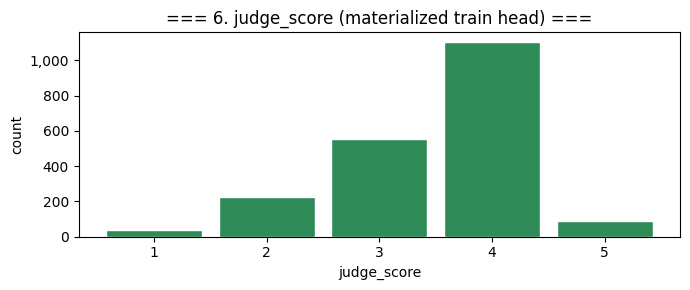

  min=1  max=5  mean=3.49


In [15]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

comma_ticks = FuncFormatter(lambda x, p: f"{x:,.0f}")

scores = [train_eda[i]["judge_score"] for i in range(len(train_eda))]

_lo, _hi = int(min(scores)), int(max(scores))
_bins = max(2, _hi - _lo + 1)

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(scores, bins=_bins, range=(_lo - 0.5, _hi + 0.5), align="mid", rwidth=0.85, color="seagreen", edgecolor="white")
ax.set_title("=== 6. judge_score (materialized train head) ===")
ax.set_xlabel("judge_score")
ax.set_ylabel("count")
ax.xaxis.set_major_formatter(comma_ticks)
ax.yaxis.set_major_formatter(comma_ticks)
plt.tight_layout()
plt.show()

print(f"  min={min(scores)}  max={max(scores)}  mean={np.mean(scores):.2f}")

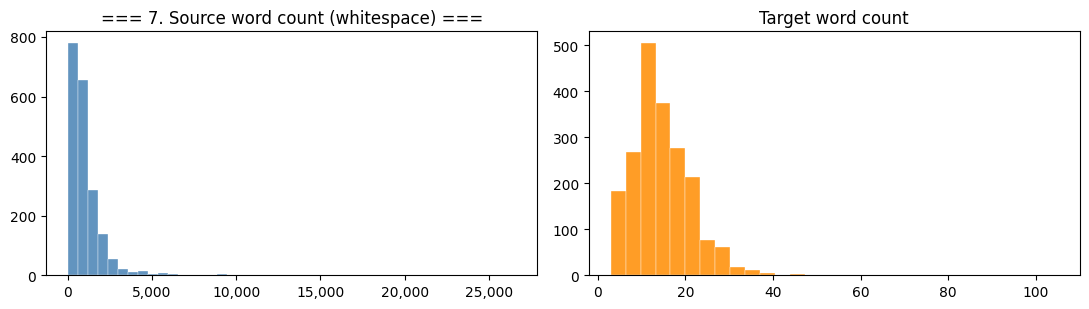

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

comma_ticks = FuncFormatter(lambda x, p: f"{x:,.0f}")

src_words = [len((train_eda[i][SOURCE_COLUMN] or "").split()) for i in range(len(train_eda))]
tgt_words = [len((train_eda[i][TARGET_COLUMN] or "").split()) for i in range(len(train_eda))]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(src_words, bins=45, color="steelblue", alpha=0.85, edgecolor="white", linewidth=0.3)
ax[0].set_title("=== 7. Source word count (whitespace) ===")
ax[1].hist(tgt_words, bins=30, color="darkorange", alpha=0.85, edgecolor="white", linewidth=0.3)
ax[1].set_title("Target word count")
for a in ax:
    a.xaxis.set_major_formatter(comma_ticks)
    a.yaxis.set_major_formatter(comma_ticks)
plt.tight_layout()
plt.show()

In [17]:
import numpy as np

src_words = [len((train_eda[i][SOURCE_COLUMN] or "").split()) for i in range(len(train_eda))]


def clip(s: str, max_chars: int = 2500) -> str:
    s = s or ""
    return s if len(s) <= max_chars else s[:max_chars] + "\n… [truncated]"


iw_min = int(np.argmin(src_words))
iw_max = int(np.argmax(src_words))

print("=== 5. Shortest vs longest source by word count (train head) ===")
print(f"  shortest row index={iw_min}  words={src_words[iw_min]:,}")
print(f"  file: {train_eda[iw_min]['file']}")
print(f"  reference: {train_eda[iw_min][TARGET_COLUMN]}")
print(clip(train_eda[iw_min][SOURCE_COLUMN]))
print()
print(f"  longest row index={iw_max}  words={src_words[iw_max]:,}")
print(f"  file: {train_eda[iw_max]['file']}")
print(f"  reference: {train_eda[iw_max][TARGET_COLUMN]}")
print(clip(train_eda[iw_max][SOURCE_COLUMN]))

=== 5. Shortest vs longest source by word count (train head) ===
  shortest row index=1030  words=38
  file: Docket16-1017_Brief001.pdf
  reference: Even if this Court has jurisdiction in Dalmazzi and Cox, it should not disturb the CAAF's discretionary denials of review
eview.  The CAAF did not 
abuse its discretion in vacating its grants of review and 
denying the petitions  in those cases  when it discovered 
that the questions it had agreed to decide were not 
squa rely presented.  
ARGUMENT

  longest row index=1199  words=26,558
  file: Docket19-46_Brief007.pdf
  reference: ALL ADMISSIBLE EVIDENCE, INCLUDING RELIABLE SURVEY EVIDENCE, SHOULD BE CONSIDERED TO DETERMINE WHETHER A TERM IS GENERIC
The PTO argues that the Respondent's Teflon 
survey is irrelevant5 because a showing of commercial 
success cannot convert a generic term into a 
trademark. As a corollary, t he PTO  also argues , based 
on cases like Hunt Masters, Inc. v. Landry's Seafood 
Restaurant, Inc ., 240 F.3d 251 (4t

In [18]:
# === 8. Subword token lengths (optional) ===
# Requires: pip install transformers
# Uses a common English checkpoint as a probe; swap for your actual seq2seq tokenizer later.

import matplotlib.pyplot as plt
import numpy as np

try:
    from transformers import AutoTokenizer

    probe_model = "bert-base-uncased"
    tok = AutoTokenizer.from_pretrained(probe_model)
    max_probe = min(500, len(train_eda))
    tok_lens = []
    for i in range(max_probe):
        enc = tok.encode(train_eda[i][SOURCE_COLUMN] or "", add_special_tokens=False)
        tok_lens.append(len(enc))
    print(f"Subword token length ({probe_model}, first {max_probe} rows of train head):")
    print(f"  min={min(tok_lens)}  p50={np.percentile(tok_lens, 50):.0f}  max={max(tok_lens)}")
    fig, ax = plt.subplots(figsize=(7, 2.8))
    ax.hist(tok_lens, bins=40, color="purple", alpha=0.8, edgecolor="white", linewidth=0.3)
    ax.set_title(f"Source subword tokens ({probe_model}, n={max_probe})")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x:,.0f}"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x:,.0f}"))
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Install transformers for subword EDA: pip install transformers")
except Exception as e:
    print(f"Tokenizer probe skipped: {e}")

Install transformers for subword EDA: pip install transformers
